In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np


In [67]:
df = pd.read_csv("Auto.csv")
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna(subset=["displacement", "horsepower"]).copy()
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [68]:
import matplotlib.pyplot as plt

In [69]:

X = df["displacement"]
Y = df["horsepower"]


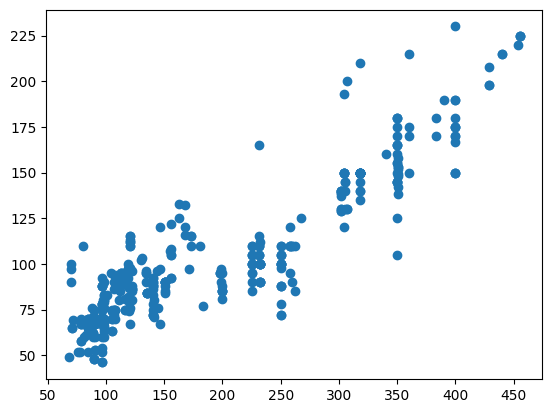

In [70]:
plt.scatter(X,Y)

In [71]:
def locally_weighted_regression(X, y, tau, x_query):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.exp(-((X - x_query) ** 2) / (2 * (tau ** 2)))
    w_sum = np.sum(w)
    if w_sum < 1.0e-12:
        return float(np.mean(y))
    return float(np.dot(w, y) / w_sum)

def lwr_predict(X_train, y_train, X_test, tau):
    X_test = np.asarray(X_test, dtype=float)
    predictions = np.array(
        [locally_weighted_regression(X_train, y_train, tau, x) for x in X_test],
        dtype=float,
    )
    return predictions

In [72]:

X_plot = np.linspace(X.min(), X.max(), 250)

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

In [74]:
from sklearn.metrics import mean_squared_error

In [76]:
taus = [ 1.0, 2.0, 5.0, 10.0, 20.0]
tau_scores = {}

for t in taus:
    y_val_pred = lwr_predict(X_train, y_train, X_val, t)
    tau_scores[t] = mean_squared_error(y_val, y_val_pred)
for t, mse in tau_scores.items():
    print(f"tau={t} , MSE={mse:.4f}")


tau=1.0 , MSE=190.4134
tau=2.0 , MSE=188.2579
tau=5.0 , MSE=188.8861
tau=10.0 , MSE=197.5578
tau=20.0 , MSE=220.5832


Test MSE: 197.9743


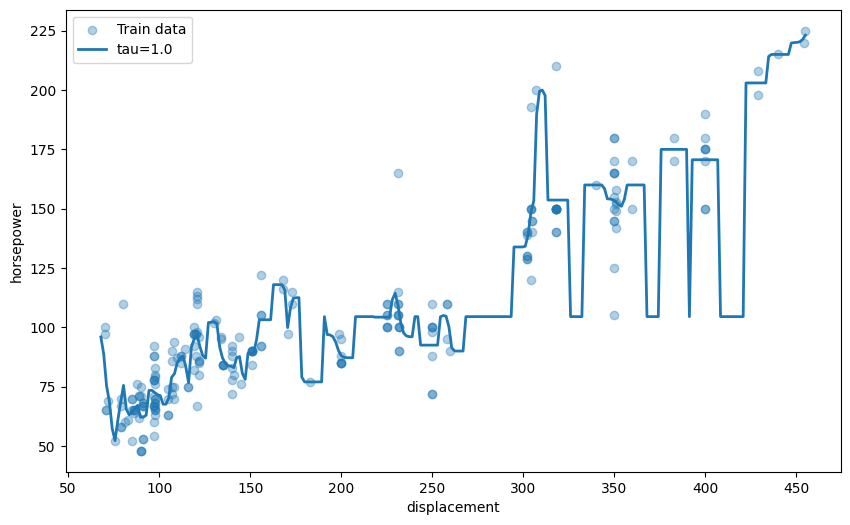

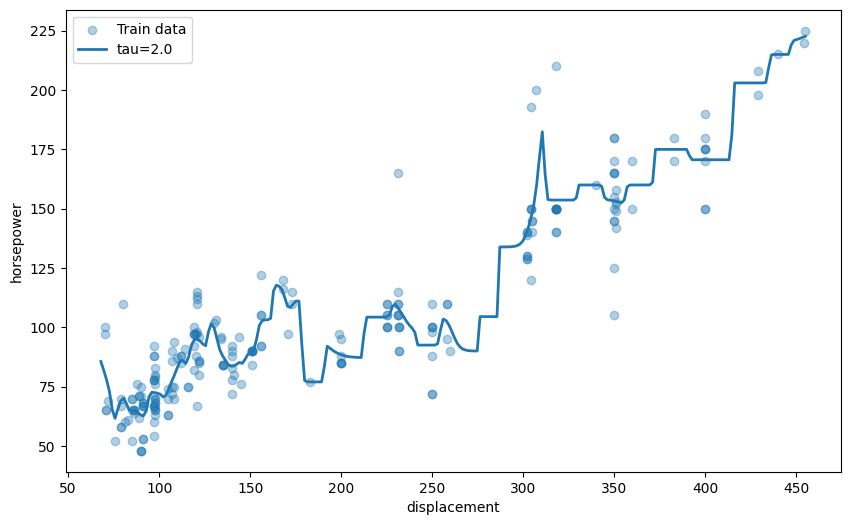

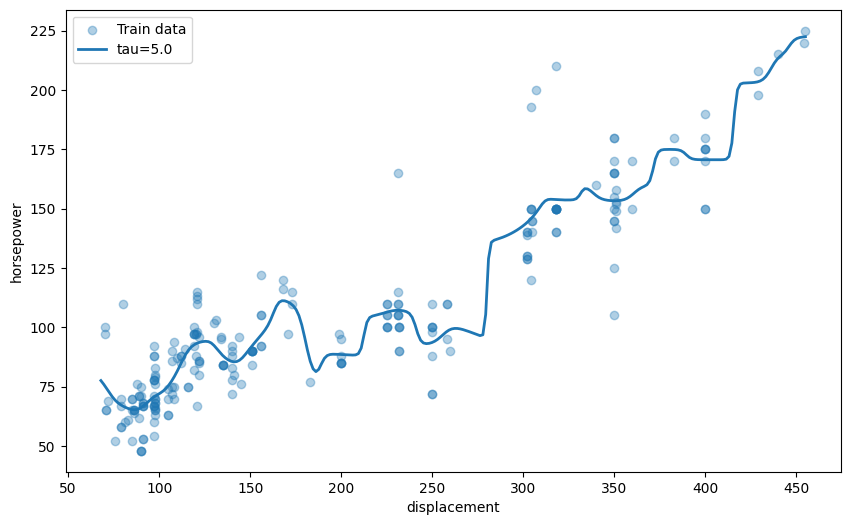

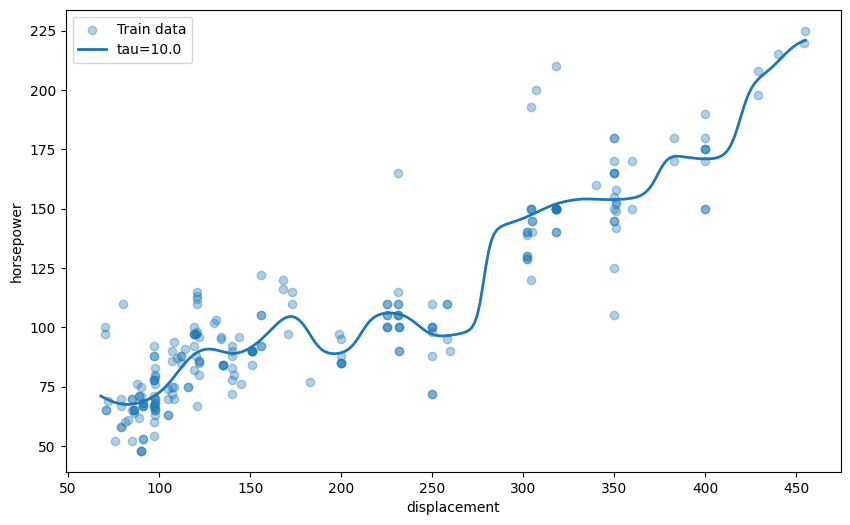

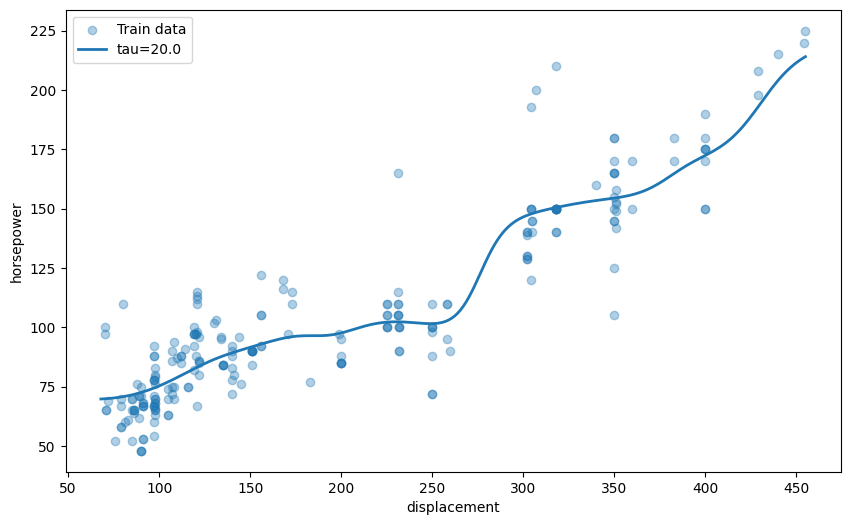

In [80]:
best_tau = min(tau_scores, key=tau_scores.get)
y_test_pred = lwr_predict(X_train, y_train, X_test, best_tau)
test_mse = mean_squared_error(y_test, y_test_pred)
print(f"Test MSE: {test_mse:.4f}")

for t in [1.0, 2.0,5.0,10.0, 20.0]:
    plt.figure(figsize=(10, 6))
    plt.scatter(X_train, y_train, alpha=0.35, label="Train data")
    y_plot = lwr_predict(X_train, y_train, X_plot, t)
    plt.plot(X_plot, y_plot, linewidth=2, label=f"tau={t}")
    plt.xlabel("displacement")
    plt.ylabel("horsepower")
    plt.legend()
    plt.show()